Notebook para a geração do gráfico de comparação das curvas de tempo de execução 

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [45]:
df = pd.read_csv('out.csv', encoding='utf-16')
df

,n_players,func,t_exec
0,100000,insert,9.364780e+01
1,100000,merge,1.405490e-01
2,66666,insert,4.203180e+01
3,66666,merge,8.491490e-02
4,44444,insert,1.908800e+01
...,...,...,...
555,3,merge,1.700000e-06
556,2,insert,4.000000e-07
557,2,merge,1.200000e-06
558,1,insert,2.000000e-07


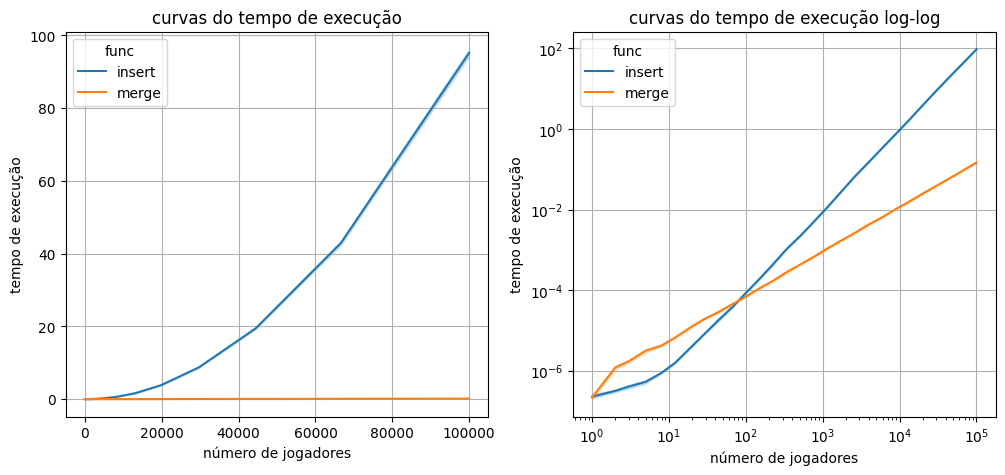

In [46]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(df, x='n_players', y='t_exec', hue='func', ax = axs[0])
sns.lineplot(df, x='n_players', y='t_exec', hue='func', ax = axs[1])
    
axs[0].set_title('curvas do tempo de execução')
axs[1].set_title('curvas do tempo de execução log-log')
axs[1].set_yscale('log')
axs[1].set_xscale('log')

for ax in axs:
    ax.set_ylabel('tempo de execução')
    ax.set_xlabel('número de jogadores')
    ax.grid(True)

C:\Users\rudab\AppData\Local\Temp\ipykernel_10596\128241824.py:10: RuntimeWarning: divide by zero encountered in log2
  sns.lineplot(x=ns, y=ns*np.log2(ns)*1e-7, ax=axs[1], label='O(n log(n))')
C:\Users\rudab\AppData\Local\Temp\ipykernel_10596\128241824.py:10: RuntimeWarning: invalid value encountered in multiply
  sns.lineplot(x=ns, y=ns*np.log2(ns)*1e-7, ax=axs[1], label='O(n log(n))')


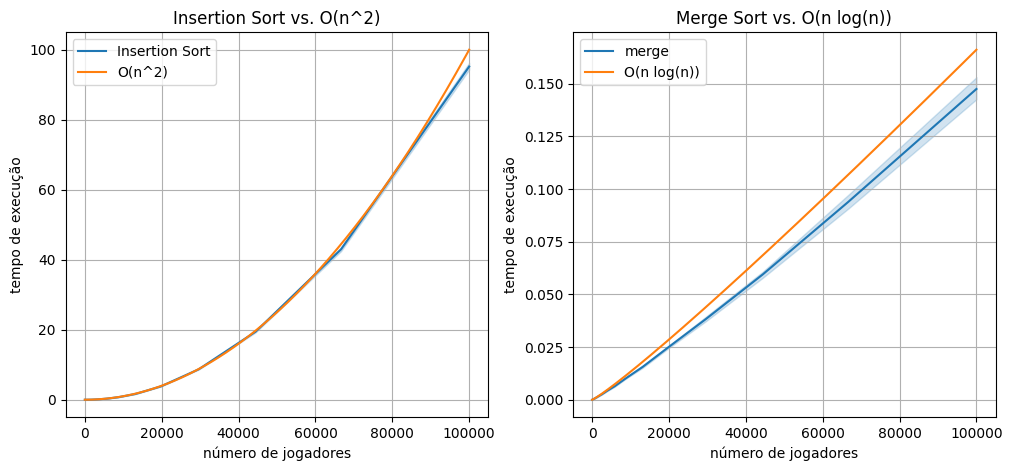

In [47]:
max_players = df.iloc[df['n_players'].idxmax()]['n_players']
ns = np.arange(max_players)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(df[df['func'] == 'insert'], x='n_players', y='t_exec', ax = axs[0], label='Insertion Sort')
sns.lineplot(x=ns, y=ns**2*1e-8, label='O(n^2)', ax=axs[0])

sns.lineplot(df[df['func'] == 'merge'], x='n_players', y='t_exec', hue='func', ax = axs[1])
sns.lineplot(x=ns, y=ns*np.log2(ns)*1e-7, ax=axs[1], label='O(n log(n))')
    
axs[0].set_title('Insertion Sort vs. O(n^2)')
axs[1].set_title('Merge Sort vs. O(n log(n))')

for ax in axs:
    ax.set_ylabel('tempo de execução')
    ax.set_xlabel('número de jogadores')
    ax.grid(True)